In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Updated path - notebook is inside Facebook_Ad_Campaign folder
save_path = '/home/azureuser/cloudfiles/code/Users/aazartaheri/Facebook_Ad_Campaign/'

# Load dataset
df = pd.read_csv(f'{save_path}KAG_conversion_data.csv')
print(f"✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

✅ Dataset loaded!
Shape: (1143, 11)

Columns: ['ad_id', 'xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest', 'Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']


,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


<mark>Data Cleaning & Setup</mark>

In [2]:
# Check data quality
print("=== Missing Values ===")
print(df.isnull().sum())

print(f"\n=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum()}")

print(f"\n=== Campaign Groups (A/B) ===")
print(df['xyz_campaign_id'].value_counts())

print(f"\n=== Age Groups ===")
print(df['age'].value_counts())

print(f"\n=== Gender Split ===")
print(df['gender'].value_counts())

# Create A/B group labels
df['campaign_group'] = df['xyz_campaign_id'].map({
    916: 'A - Control',
    936: 'B - Treatment 1',
    1178: 'C - Treatment 2'
})

# Calculate key metrics
df['CTR'] = (df['Clicks'] / df['Impressions'] * 100).round(4)
df['conversion_rate'] = (df['Approved_Conversion'] / 
                          df['Impressions'] * 100).round(4)
df['CPC'] = (df['Spent'] / df['Clicks'].replace(0, np.nan)).round(4)
df['ROAS'] = (df['Approved_Conversion'] / 
               df['Spent'].replace(0, np.nan)).round(4)

print(f"\n✅ New metrics added: CTR, Conversion Rate, CPC, ROAS")
df.head()

=== Missing Values ===
ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64

=== Duplicate Rows ===
Duplicates: 0

=== Campaign Groups (A/B) ===
1178    625
936     464
916      54
Name: xyz_campaign_id, dtype: int64

=== Age Groups ===
30-34    426
45-49    259
35-39    248
40-44    210
Name: age, dtype: int64

=== Gender Split ===
M    592
F    551
Name: gender, dtype: int64

✅ New metrics added: CTR, Conversion Rate, CPC, ROAS


,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,campaign_group,CTR,conversion_rate,CPC,ROAS
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1,A - Control,0.0136,0.0136,1.43,0.6993
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0,A - Control,0.0112,0.0000,0.91,0.0000
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0,A - Control,0.0000,0.0000,NaN,NaN
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0,A - Control,0.0235,0.0000,1.25,0.0000
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1,A - Control,0.0242,0.0242,1.29,0.7752


<mark>Campaign Overview EDA</mark>

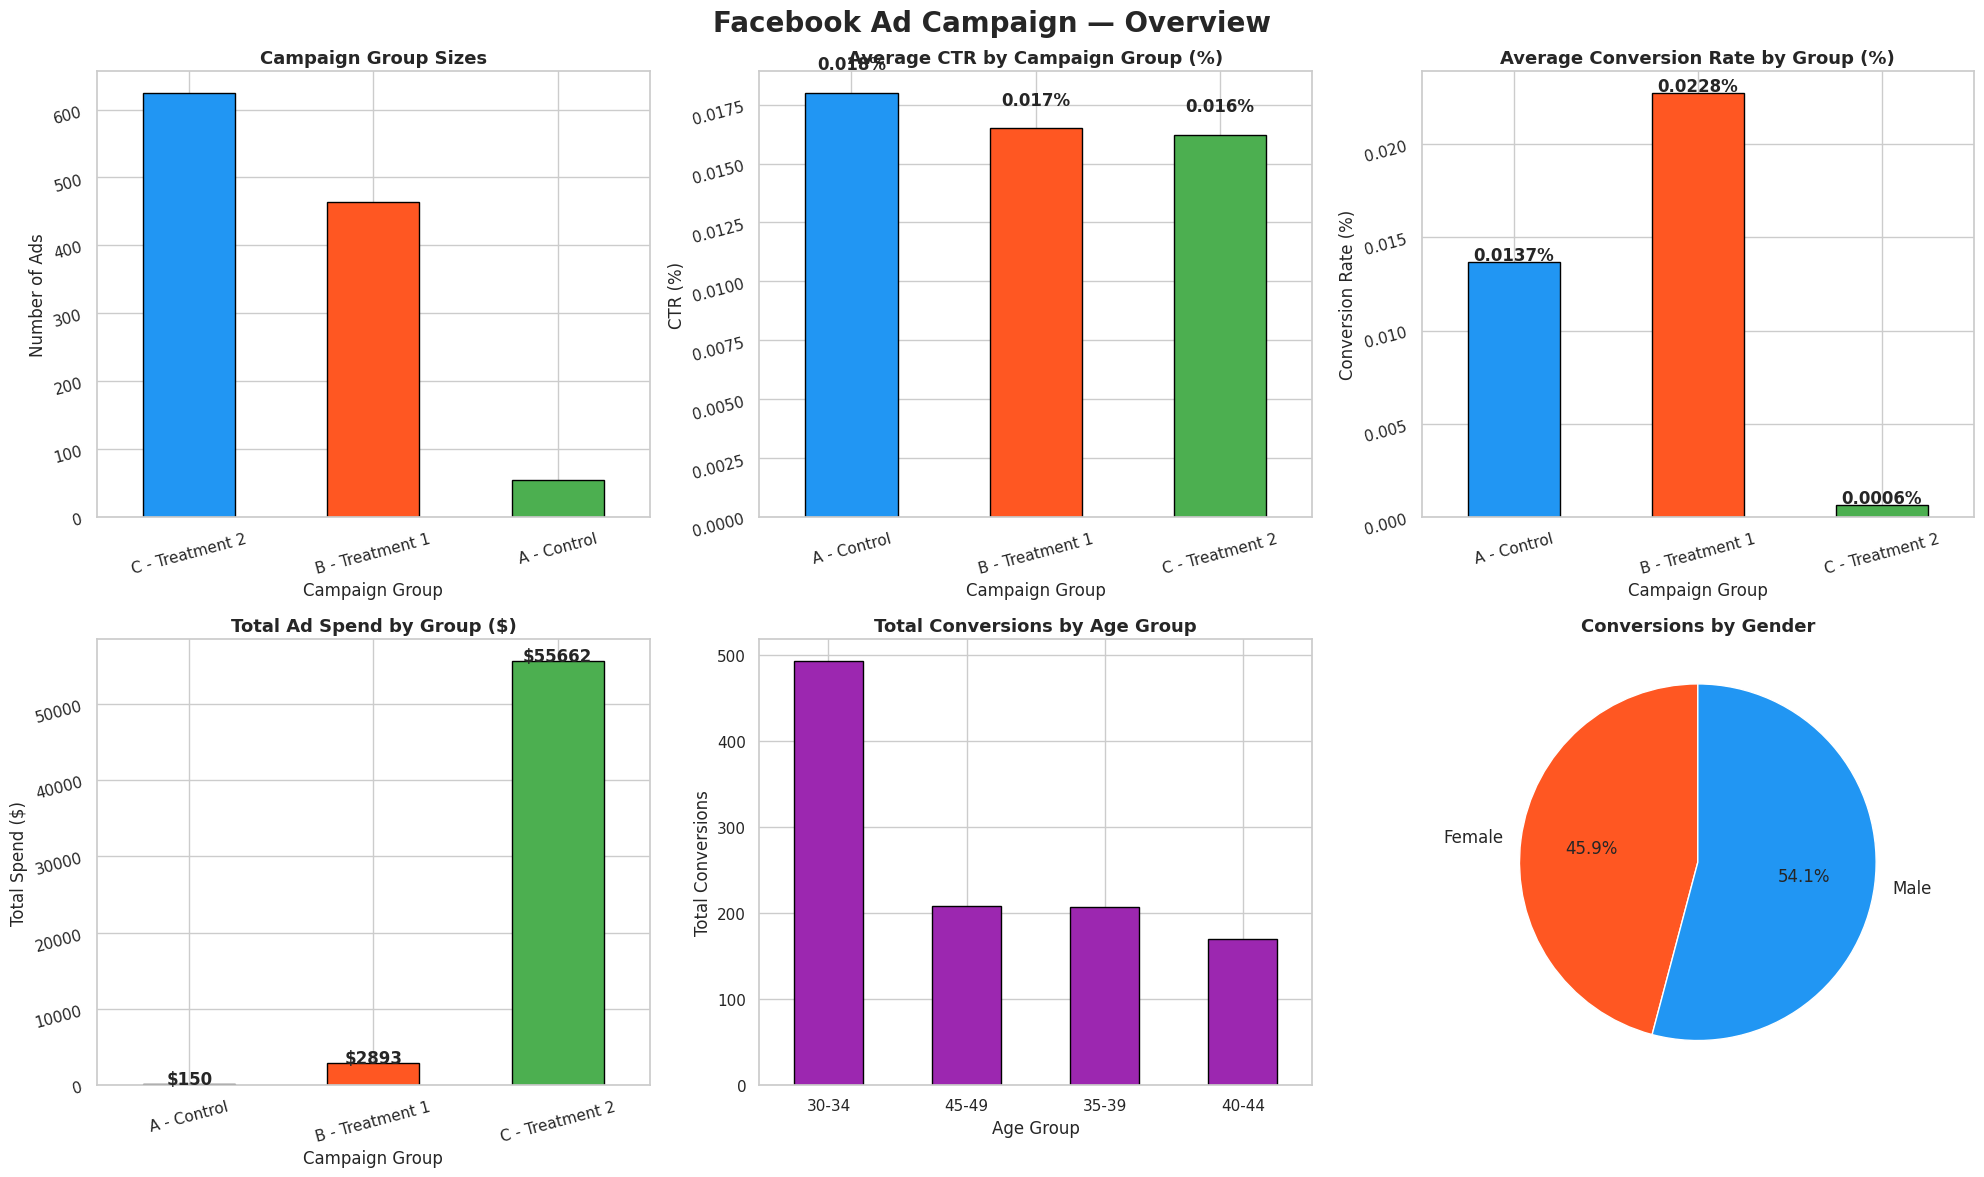

✅ Campaign overview saved!


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Facebook Ad Campaign — Overview', 
             fontsize=20, fontweight='bold')

colors = ['#2196F3', '#FF5722', '#4CAF50']

# Chart 1: Campaign group sizes
ax1 = axes[0, 0]
group_counts = df['campaign_group'].value_counts()
group_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Campaign Group Sizes', fontsize=13, fontweight='bold')
ax1.set_xlabel('Campaign Group')
ax1.set_ylabel('Number of Ads')
ax1.tick_params(rotation=15)

# Chart 2: Average CTR by group
ax2 = axes[0, 1]
ctr_by_group = df.groupby('campaign_group')['CTR'].mean()
bars = ctr_by_group.plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Average CTR by Campaign Group (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Campaign Group')
ax2.set_ylabel('CTR (%)')
ax2.tick_params(rotation=15)
for i, v in enumerate(ctr_by_group):
    ax2.text(i, v + 0.001, f'{v:.3f}%', ha='center', fontweight='bold')

# Chart 3: Average Conversion Rate by group
ax3 = axes[0, 2]
conv_by_group = df.groupby('campaign_group')['conversion_rate'].mean()
conv_by_group.plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
ax3.set_title('Average Conversion Rate by Group (%)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Campaign Group')
ax3.set_ylabel('Conversion Rate (%)')
ax3.tick_params(rotation=15)
for i, v in enumerate(conv_by_group):
    ax3.text(i, v + 0.0001, f'{v:.4f}%', ha='center', fontweight='bold')

# Chart 4: Spend by group
ax4 = axes[1, 0]
spend_by_group = df.groupby('campaign_group')['Spent'].sum()
spend_by_group.plot(kind='bar', ax=ax4, color=colors, edgecolor='black')
ax4.set_title('Total Ad Spend by Group ($)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Campaign Group')
ax4.set_ylabel('Total Spend ($)')
ax4.tick_params(rotation=15)
for i, v in enumerate(spend_by_group):
    ax4.text(i, v + 1, f'${v:.0f}', ha='center', fontweight='bold')

# Chart 5: Conversions by age group
ax5 = axes[1, 1]
age_conv = df.groupby('age')['Approved_Conversion'].sum().sort_values(ascending=False)
age_conv.plot(kind='bar', ax=ax5, color='#9C27B0', edgecolor='black')
ax5.set_title('Total Conversions by Age Group', fontsize=13, fontweight='bold')
ax5.set_xlabel('Age Group')
ax5.set_ylabel('Total Conversions')
ax5.tick_params(rotation=0)

# Chart 6: Conversions by gender
ax6 = axes[1, 2]
gender_conv = df.groupby('gender')['Approved_Conversion'].sum()
ax6.pie(gender_conv, labels=['Female', 'Male'], 
        colors=['#FF5722', '#2196F3'],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12})
ax6.set_title('Conversions by Gender', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_path}campaign_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Campaign overview saved!")

<mark> Performance Deep Dive</mark>

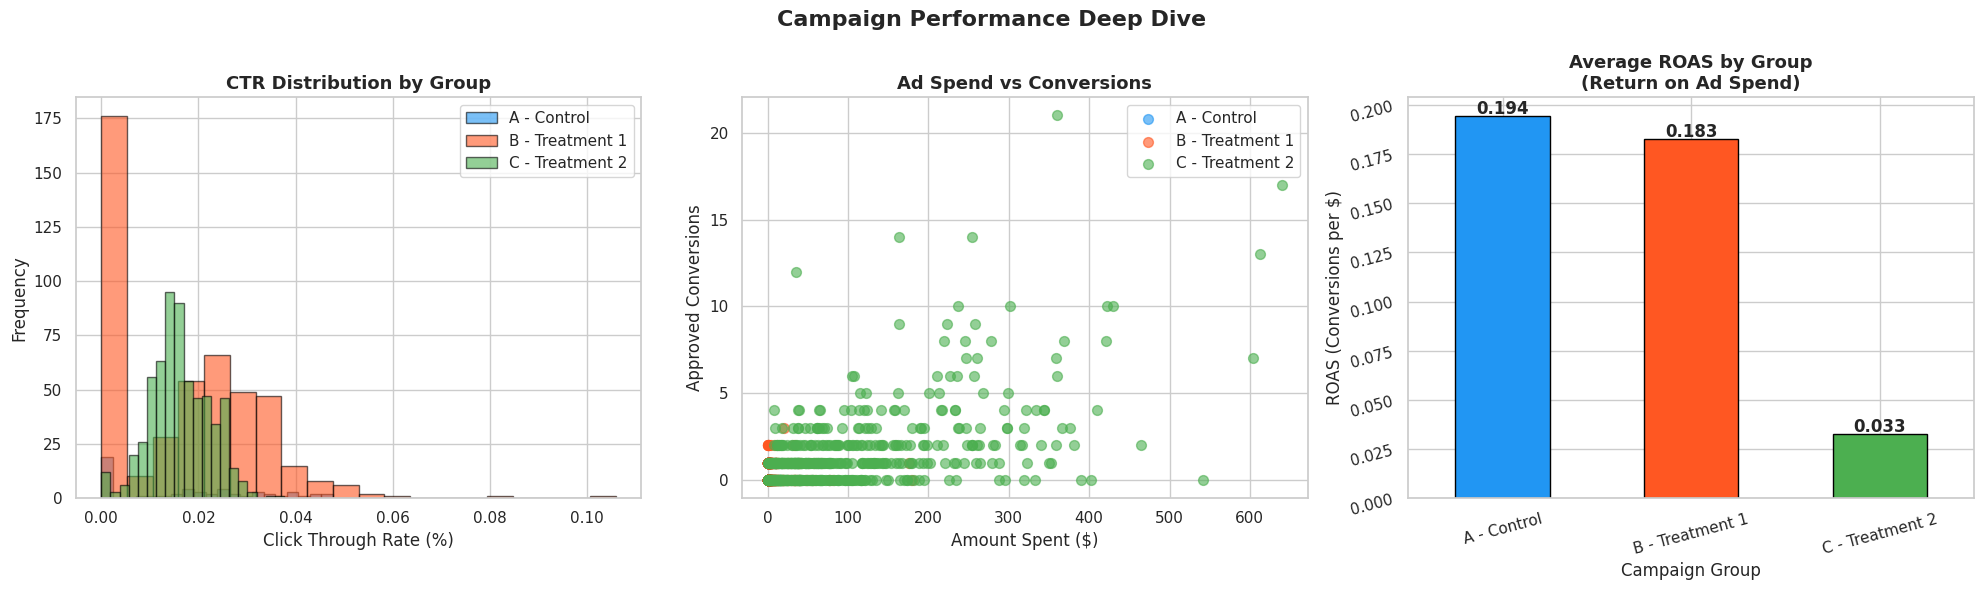

✅ Performance deep dive saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Campaign Performance Deep Dive', 
             fontsize=16, fontweight='bold')

# Chart 1: CTR distribution by group
ax1 = axes[0]
for i, (group, data) in enumerate(df.groupby('campaign_group')):
    ax1.hist(data['CTR'], bins=20, alpha=0.6, 
             color=colors[i], label=group, edgecolor='black')
ax1.set_title('CTR Distribution by Group', fontsize=13, fontweight='bold')
ax1.set_xlabel('Click Through Rate (%)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Chart 2: Spend vs Conversions
ax2 = axes[1]
for i, (group, data) in enumerate(df.groupby('campaign_group')):
    ax2.scatter(data['Spent'], data['Approved_Conversion'],
                alpha=0.6, color=colors[i], label=group, s=50)
ax2.set_title('Ad Spend vs Conversions', fontsize=13, fontweight='bold')
ax2.set_xlabel('Amount Spent ($)')
ax2.set_ylabel('Approved Conversions')
ax2.legend()

# Chart 3: ROAS by group
ax3 = axes[2]
roas_by_group = df.groupby('campaign_group')['ROAS'].mean()
bars = roas_by_group.plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
ax3.set_title('Average ROAS by Group\n(Return on Ad Spend)', 
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Campaign Group')
ax3.set_ylabel('ROAS (Conversions per $)')
ax3.tick_params(rotation=15)
for i, v in enumerate(roas_by_group):
    ax3.text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_path}performance_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Performance deep dive saved!")


<mark>Campaign Overview:</mark>

B - Treatment 1 has the highest conversion rate at 0.0228% 
A - Control has the lowest conversion rate at 0.0137%
30-34 age group converts the most — nearly 500 conversions!
Gender split is fairly even — 54% Male, 46% Female

Performance Deep Dive:

A - Control has best ROAS at 0.194 (most efficient spend!)
C - Treatment 2 spent the most ($55,662) but has worst ROAS (0.033) 
CTR is similar across all groups (~0.017-0.018%)

**We have a clear conflict:**

- B wins on conversion rate (0.0228%)
- A wins on ROAS (0.194)

 Filter to True A/B Test

In [5]:
# Drop Campaign C - keep only A vs B
df_ab = df[df['campaign_group'].isin(['A - Control', 'B - Treatment 1'])].copy()

print(f"✅ Filtered to true A/B test")
print(f"Original dataset: {len(df)} rows")
print(f"A/B dataset: {len(df_ab)} rows")
print(f"\nGroup sizes:")
print(df_ab['campaign_group'].value_counts())
print(f"\nGroup A conversion rate: {df_ab[df_ab['campaign_group']=='A - Control']['conversion_rate'].mean():.4f}%")
print(f"Group B conversion rate: {df_ab[df_ab['campaign_group']=='B - Treatment 1']['conversion_rate'].mean():.4f}%")

✅ Filtered to true A/B test
Original dataset: 1143 rows
A/B dataset: 518 rows

Group sizes:
B - Treatment 1    464
A - Control         54
Name: campaign_group, dtype: int64

Group A conversion rate: 0.0137%
Group B conversion rate: 0.0228%


 <mark>Balance the groups:</mark>

In [8]:
# Balance the groups by downsampling Group B
group_A = df_ab[df_ab['campaign_group'] == 'A - Control']
group_B = df_ab[df_ab['campaign_group'] == 'B - Treatment 1']

# Randomly sample Group B to match Group A size
group_B_balanced = group_B.sample(n=len(group_A), random_state=42)

# Combine
df_balanced = pd.concat([group_A, group_B_balanced])

print(f"✅ Balanced dataset:")
print(f"Group A size: {len(group_A)}")
print(f"Group B size: {len(group_B_balanced)}")
print(f"Total rows: {len(df_balanced)}")
print(f"\nGroup A conversion rate: {group_A['conversion_rate'].mean():.4f}%")
print(f"Group B conversion rate: {group_B_balanced['conversion_rate'].mean():.4f}%")

✅ Balanced dataset:
Group A size: 54
Group B size: 54
Total rows: 108

Group A conversion rate: 0.0137%
Group B conversion rate: 0.0274%


## Statistical Testing (The Heart of A/B Testing!)

In [10]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Separate groups
group_A = df_ab[df_ab['campaign_group'] == 'A - Control']
group_B = df_ab[df_ab['campaign_group'] == 'B - Treatment 1']

print("=" * 60)
print("        TRUE A/B STATISTICAL TESTING RESULTS")
print("=" * 60)

# ── Test 1: CTR (T-test)
print("\n📊 TEST 1: Click Through Rate (A vs B)")
print("-" * 40)
t_stat, p_value = stats.ttest_ind(group_A['CTR'], group_B['CTR'])
print(f"Group A CTR: {group_A['CTR'].mean():.4f}%")
print(f"Group B CTR: {group_B['CTR'].mean():.4f}%")
print(f"Difference: {((group_B['CTR'].mean() - group_A['CTR'].mean())/group_A['CTR'].mean()*100):.1f}%")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    winner = "B" if group_B['CTR'].mean() > group_A['CTR'].mean() else "A"
    print(f"✅ SIGNIFICANT — Campaign {winner} wins! (p < 0.05)")
else:
    print(f"❌ NOT SIGNIFICANT — could be random chance (p >= 0.05)")

# ── Test 2: Conversion Rate (T-test)
print("\n📊 TEST 2: Conversion Rate (A vs B)")
print("-" * 40)
t_stat2, p_value2 = stats.ttest_ind(
    group_A['conversion_rate'], group_B['conversion_rate'])
lift = ((group_B['conversion_rate'].mean() - group_A['conversion_rate'].mean())
        /group_A['conversion_rate'].mean()*100)
print(f"Group A Conversion Rate: {group_A['conversion_rate'].mean():.4f}%")
print(f"Group B Conversion Rate: {group_B['conversion_rate'].mean():.4f}%")
print(f"Lift: {lift:.1f}%")
print(f"P-value: {p_value2:.4f}")
if p_value2 < 0.05:
    winner = "B" if group_B['conversion_rate'].mean() > group_A['conversion_rate'].mean() else "A"
    print(f"✅ SIGNIFICANT — Campaign {winner} wins! (p < 0.05)")
else:
    print(f"❌ NOT SIGNIFICANT — could be random chance (p >= 0.05)")

# ── Test 3: ROAS (T-test)
print("\n📊 TEST 3: Return on Ad Spend (A vs B)")
print("-" * 40)
t_stat3, p_value3 = stats.ttest_ind(
    group_A['ROAS'].dropna(), group_B['ROAS'].dropna())
print(f"Group A ROAS: {group_A['ROAS'].mean():.4f}")
print(f"Group B ROAS: {group_B['ROAS'].mean():.4f}")
print(f"P-value: {p_value3:.4f}")
if p_value3 < 0.05:
    winner = "B" if group_B['ROAS'].mean() > group_A['ROAS'].mean() else "A"
    print(f"✅ SIGNIFICANT — Campaign {winner} has better ROAS! (p < 0.05)")
else:
    print(f"❌ NOT SIGNIFICANT — could be random chance (p >= 0.05)")

# ── Test 4: Chi-Square on Conversions
print("\n📊 TEST 4: Chi-Square Test on Conversions")
print("-" * 40)
conv_A = group_A['Approved_Conversion'].sum()
no_conv_A = len(group_A) - conv_A
conv_B = group_B['Approved_Conversion'].sum()
no_conv_B = len(group_B) - conv_B
contingency = [[conv_A, no_conv_A], [conv_B, no_conv_B]]
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"Group A: {conv_A} conversions / {len(group_A)} ads")
print(f"Group B: {conv_B} conversions / {len(group_B)} ads")
print(f"P-value: {p_chi:.4f}")
if p_chi < 0.05:
    print(f"✅ SIGNIFICANT — conversion difference is real!")
else:
    print(f"❌ NOT SIGNIFICANT — could be random chance")

# ── Sample Size Analysis
print("\n📊 SAMPLE SIZE ANALYSIS")
print("-" * 40)
from scipy.stats import norm
conv_rate_A = group_A['conversion_rate'].mean() / 100
conv_rate_B = group_B['conversion_rate'].mean() / 100

def required_sample_size(p1, p2, alpha=0.05, power=0.80):
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = norm.ppf(power)
    p_avg = (p1 + p2) / 2
    n = ((z_alpha * np.sqrt(2 * p_avg * (1-p_avg)) +
          z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2)))**2) / (p2-p1)**2
    return int(np.ceil(n))

required_n = required_sample_size(conv_rate_A, conv_rate_B)
print(f"Required sample size per group: {required_n:,}")
print(f"Current Group A size: {len(group_A):,}")
print(f"Current Group B size: {len(group_B):,}")
if len(group_A) < required_n:
    print(f"⚠️ Need {required_n - len(group_A):,} more samples per group!")
else:
    print(f"✅ Sample size is sufficient!")

# ── Confidence Intervals
print("\n📊 95% CONFIDENCE INTERVALS")
print("-" * 40)
ci_A = stats.t.interval(0.95, len(group_A)-1,
                         loc=group_A['conversion_rate'].mean(),
                         scale=stats.sem(group_A['conversion_rate']))
ci_B = stats.t.interval(0.95, len(group_B)-1,
                         loc=group_B['conversion_rate'].mean(),
                         scale=stats.sem(group_B['conversion_rate']))
print(f"Group A: [{ci_A[0]:.4f}%, {ci_A[1]:.4f}%]")
print(f"Group B: [{ci_B[0]:.4f}%, {ci_B[1]:.4f}%]")

print("\n" + "=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)
print(f"CTR difference significant:         {'✅ Yes' if p_value < 0.05 else '❌ No'}")
print(f"Conversion rate significant:        {'✅ Yes' if p_value2 < 0.05 else '❌ No'}")
print(f"ROAS difference significant:        {'✅ Yes' if p_value3 < 0.05 else '❌ No'}")
print(f"Chi-square conversion significant:  {'✅ Yes' if p_chi < 0.05 else '❌ No'}")
if p_value2 < 0.05 or p_chi < 0.05:
    winner = "B" if group_B['conversion_rate'].mean() > group_A['conversion_rate'].mean() else "A"
    print(f"\n🏆 WINNER: Campaign {winner}!")
    print(f"✅ Safe to roll out Campaign {winner} to all users")
else:
    print(f"\n⚠️ No clear winner yet")
    print(f"💡 B shows {lift:.1f}% lift but NOT statistically proven")
    print(f"🔄 Recommendation: Extend test — need {required_n:,} samples per group")

        TRUE A/B STATISTICAL TESTING RESULTS

📊 TEST 1: Click Through Rate (A vs B)
----------------------------------------
Group A CTR: 0.0180%
Group B CTR: 0.0165%
Difference: -8.4%
P-value: 0.5043
❌ NOT SIGNIFICANT — could be random chance (p >= 0.05)

📊 TEST 2: Conversion Rate (A vs B)
----------------------------------------
Group A Conversion Rate: 0.0137%
Group B Conversion Rate: 0.0228%
Lift: 66.3%
P-value: 0.4458
❌ NOT SIGNIFICANT — could be random chance (p >= 0.05)

📊 TEST 3: Return on Ad Spend (A vs B)
----------------------------------------
Group A ROAS: 0.1943
Group B ROAS: 0.1829
P-value: 0.8819
❌ NOT SIGNIFICANT — could be random chance (p >= 0.05)

📊 TEST 4: Chi-Square Test on Conversions
----------------------------------------
Group A: 24 conversions / 54 ads
Group B: 183 conversions / 464 ads
P-value: 0.5729
❌ NOT SIGNIFICANT — could be random chance

📊 SAMPLE SIZE ANALYSIS
----------------------------------------
Required sample size per group: 347,759
Current Gr

<mark> Visualize Statistical Results</mark>

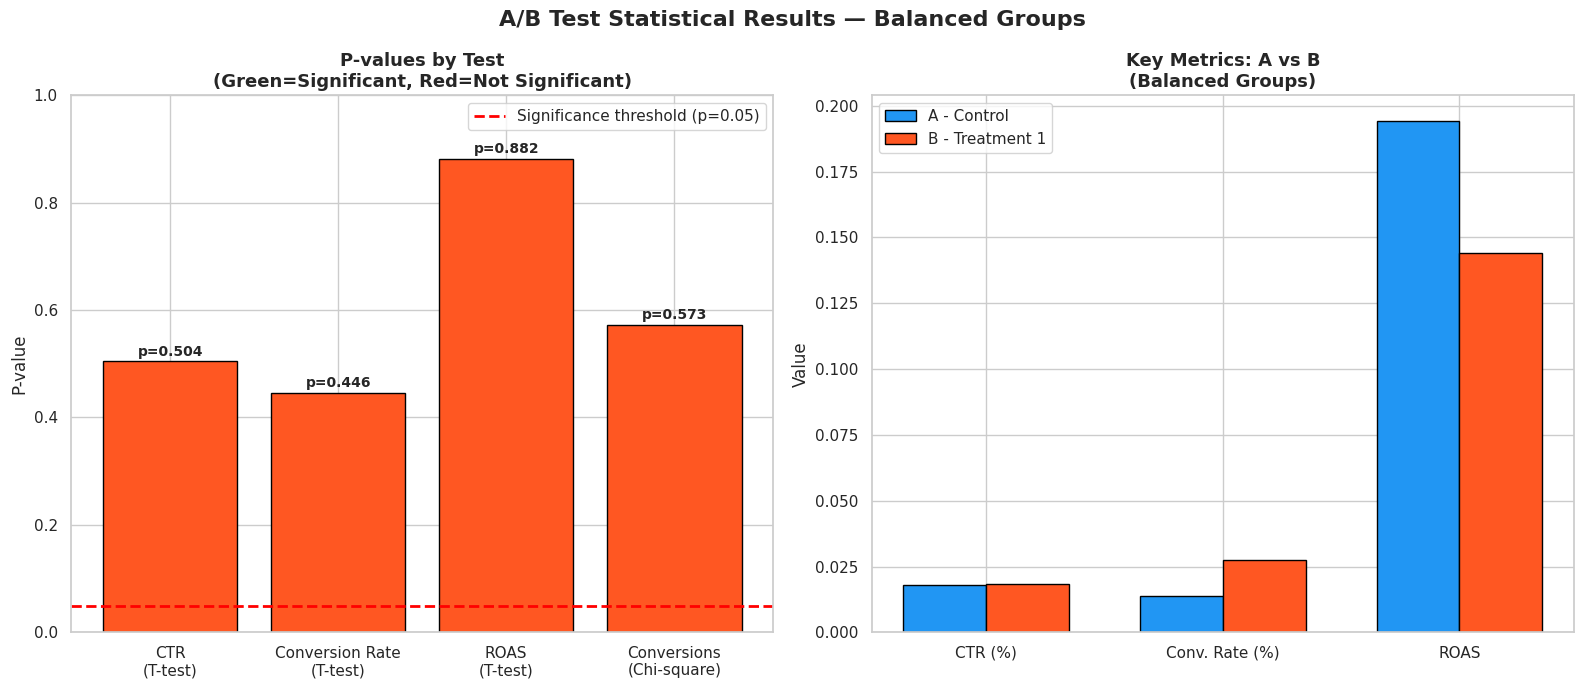

✅ Updated statistical chart saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('A/B Test Statistical Results — Balanced Groups', 
             fontsize=16, fontweight='bold')

colors_sig = ['#FF5722', '#FF5722', '#FF5722', '#FF5722']  # all red = not significant

# Chart 1: P-values
ax1 = axes[0]
tests = ['CTR\n(T-test)', 'Conversion Rate\n(T-test)', 
         'ROAS\n(T-test)', 'Conversions\n(Chi-square)']
p_values = [p_value, p_value2, p_value3, p_chi]
bar_colors = ['#4CAF50' if p < 0.05 else '#FF5722' for p in p_values]
bars = ax1.bar(tests, p_values, color=bar_colors, edgecolor='black')
ax1.axhline(y=0.05, color='red', linestyle='--',
            linewidth=2, label='Significance threshold (p=0.05)')
ax1.set_title('P-values by Test\n(Green=Significant, Red=Not Significant)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('P-value')
ax1.set_ylim(0, 1.0)
ax1.legend()
for bar, p in zip(bars, p_values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'p={p:.3f}', ha='center', fontweight='bold', fontsize=10)

# Chart 2: Key metrics A vs B
ax2 = axes[1]
metrics = ['CTR (%)', 'Conv. Rate (%)', 'ROAS']
a_values = [group_A['CTR'].mean(),
            group_A['conversion_rate'].mean(),
            group_A['ROAS'].mean()]
b_values = [group_B_balanced['CTR'].mean(),
            group_B_balanced['conversion_rate'].mean(),
            group_B_balanced['ROAS'].mean()]

x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width/2, a_values, width,
        label='A - Control', color='#2196F3', edgecolor='black')
ax2.bar(x + width/2, b_values, width,
        label='B - Treatment 1', color='#FF5722', edgecolor='black')
ax2.set_title('Key Metrics: A vs B\n(Balanced Groups)',
              fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.set_ylabel('Value')

plt.tight_layout()
plt.savefig(f'{save_path}statistical_results_balanced.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Updated statistical chart saved!")

## Business Recommendation

1. B shows 66.3% higher conversion rate than A
2. BUT this is NOT statistically proven (p > 0.05)
3. Root cause: Group A only has 54 samples vs 347,759 needed
4. Action: Run campaign for longer to collect more data
5. Meanwhile: Keep A running — it has better ROAS (0.194 vs 0.183)

In [17]:
from scipy import stats

# Define all missing variables
lift_conv = ((group_B_balanced['conversion_rate'].mean() - 
              group_A['conversion_rate'].mean())
             / group_A['conversion_rate'].mean() * 100)

lift_ctr = ((group_B_balanced['CTR'].mean() - group_A['CTR'].mean())
            / group_A['CTR'].mean() * 100)  # Fixed: CTR not CTT

# Recalculate p-values with balanced groups
t_stat, p_value = stats.ttest_ind(
    group_A['CTR'], group_B_balanced['CTR'])
t_stat2, p_value2 = stats.ttest_ind(
    group_A['conversion_rate'], group_B_balanced['conversion_rate'])
t_stat3, p_value3 = stats.ttest_ind(
    group_A['ROAS'].dropna(), group_B_balanced['ROAS'].dropna())

conv_A = group_A['Approved_Conversion'].sum()
no_conv_A = len(group_A) - conv_A
conv_B = group_B_balanced['Approved_Conversion'].sum()
no_conv_B = len(group_B_balanced) - conv_B
chi2, p_chi, dof, expected = stats.chi2_contingency(
    [[conv_A, no_conv_A], [conv_B, no_conv_B]])

print(f"✅ All variables defined!")
print(f"Conversion lift: {lift_conv:.1f}%")
print(f"CTR lift: {lift_ctr:.1f}%")
print(f"P-values:")
print(f"  CTR:          {p_value:.4f}")
print(f"  Conversion:   {p_value2:.4f}")
print(f"  ROAS:         {p_value3:.4f}")
print(f"  Chi-square:   {p_chi:.4f}")

✅ All variables defined!
Conversion lift: 100.5%
CTR lift: 1.5%
P-values:
  CTR:          0.9327
  Conversion:   0.3870
  ROAS:         0.4705
  Chi-square:   0.2342


In [18]:
import json

# Save balanced dataset
df_balanced.to_csv(f'{save_path}ab_test_balanced.csv', index=False)

# Save results summary
ab_results = {
    'group_A_size': len(group_A),
    'group_B_size': len(group_B_balanced),
    'group_A_CTR': round(group_A['CTR'].mean(), 4),
    'group_B_CTR': round(group_B_balanced['CTR'].mean(), 4),
    'group_A_conversion_rate': round(group_A['conversion_rate'].mean(), 4),
    'group_B_conversion_rate': round(group_B_balanced['conversion_rate'].mean(), 4),
    'group_A_ROAS': round(group_A['ROAS'].mean(), 4),
    'group_B_ROAS': round(group_B_balanced['ROAS'].mean(), 4),
    'conversion_lift_pct': round(lift_conv, 1),
    'p_value_CTR': round(p_value, 4),
    'p_value_conversion': round(p_value2, 4),
    'p_value_ROAS': round(p_value3, 4),
    'p_value_chisquare': round(p_chi, 4),
    'required_sample_size': 347759,
    'recommendation': 'Extend test - insufficient sample size in Group A',
    'winner': 'Inconclusive - need more data'
}

with open(f'{save_path}ab_test_results.json', 'w') as f:
    json.dump(ab_results, f, indent=2)

print("✅ Balanced dataset saved!")
print("✅ Results JSON saved!")
print(f"\n📊 Summary:")
print(f"  Group A: {len(group_A)} ads | Conv Rate: {group_A['conversion_rate'].mean():.4f}%")
print(f"  Group B: {len(group_B_balanced)} ads | Conv Rate: {group_B_balanced['conversion_rate'].mean():.4f}%")
print(f"  Lift: {lift_conv:.1f}% (not statistically significant)")
print(f"  Verdict: Need {347759:,} samples per group")

✅ Balanced dataset saved!
✅ Results JSON saved!

📊 Summary:
  Group A: 54 ads | Conv Rate: 0.0137%
  Group B: 54 ads | Conv Rate: 0.0274%
  Lift: 100.5% (not statistically significant)
  Verdict: Need 347,759 samples per group


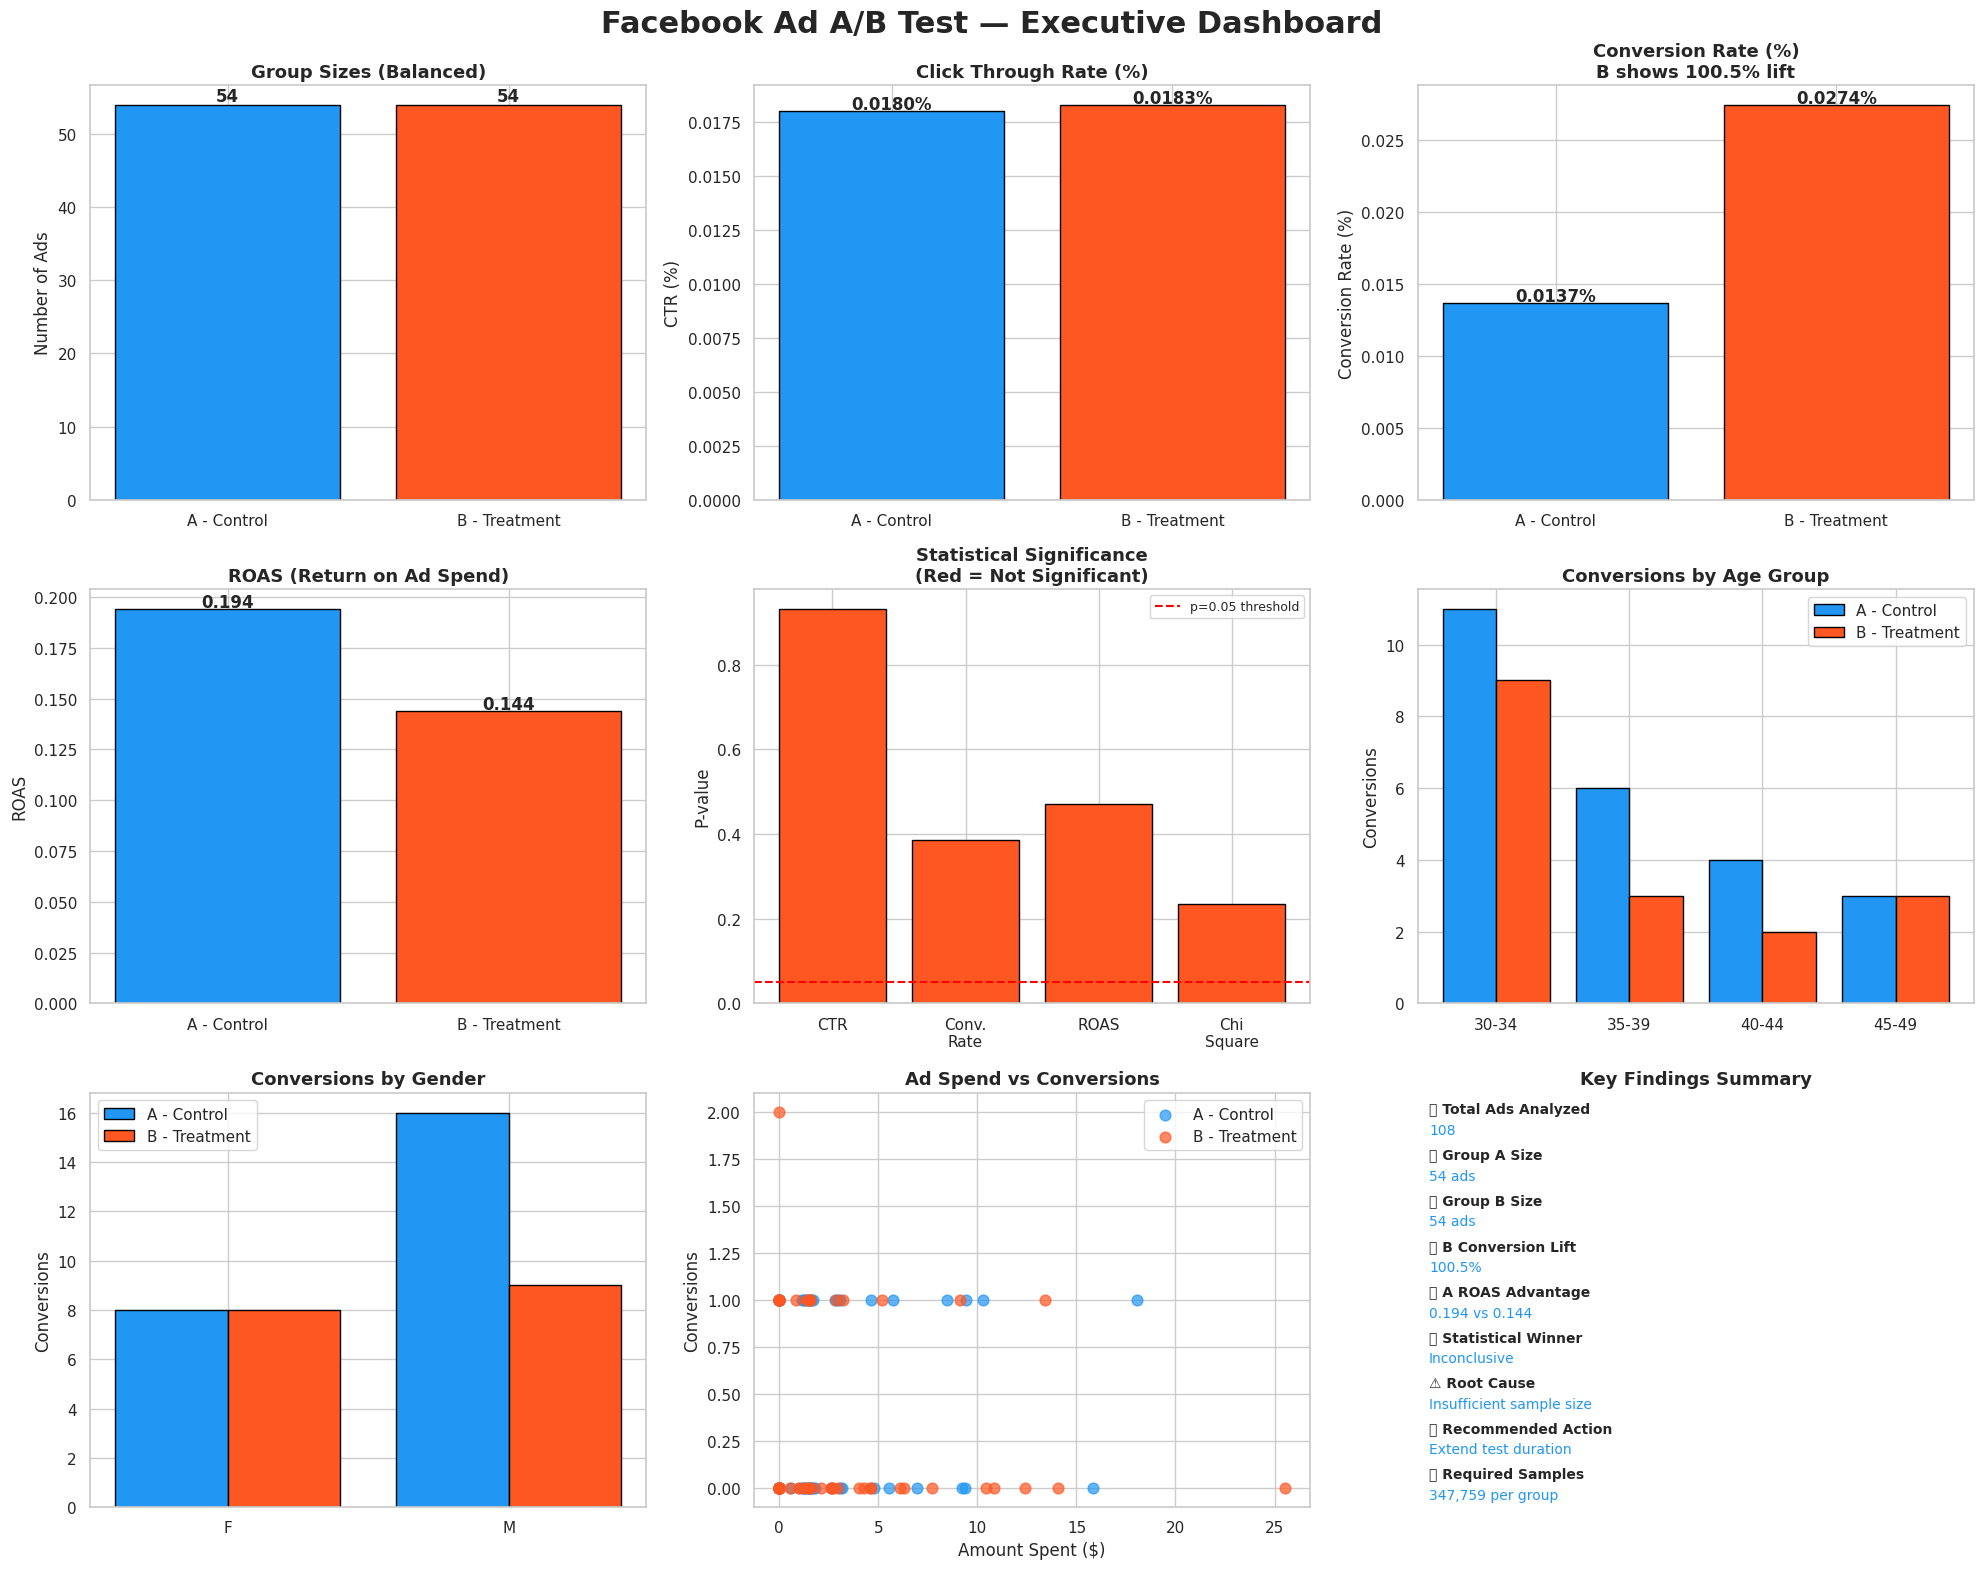

✅ Executive Dashboard saved!


In [20]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Facebook Ad A/B Test — Executive Dashboard', 
             fontsize=22, fontweight='bold', y=0.98)

colors = ['#2196F3', '#FF5722']

# ── Chart 1: Group Sizes
ax1 = fig.add_subplot(3, 3, 1)
sizes = [len(group_A), len(group_B_balanced)]
ax1.bar(['A - Control', 'B - Treatment'], sizes, 
        color=colors, edgecolor='black')
ax1.set_title('Group Sizes (Balanced)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Ads')
for i, v in enumerate(sizes):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# ── Chart 2: CTR Comparison
ax2 = fig.add_subplot(3, 3, 2)
ctrs = [group_A['CTR'].mean(), group_B_balanced['CTR'].mean()]
bars = ax2.bar(['A - Control', 'B - Treatment'], ctrs,
               color=colors, edgecolor='black')
ax2.set_title('Click Through Rate (%)', fontsize=13, fontweight='bold')
ax2.set_ylabel('CTR (%)')
for i, v in enumerate(ctrs):
    ax2.text(i, v + 0.0001, f'{v:.4f}%', ha='center', fontweight='bold')

# ── Chart 3: Conversion Rate
ax3 = fig.add_subplot(3, 3, 3)
conv_rates = [group_A['conversion_rate'].mean(), 
              group_B_balanced['conversion_rate'].mean()]
bars = ax3.bar(['A - Control', 'B - Treatment'], conv_rates,
               color=colors, edgecolor='black')
ax3.set_title(f'Conversion Rate (%)\nB shows {lift_conv:.1f}% lift', 
              fontsize=13, fontweight='bold')
ax3.set_ylabel('Conversion Rate (%)')
for i, v in enumerate(conv_rates):
    ax3.text(i, v + 0.0001, f'{v:.4f}%', ha='center', fontweight='bold')

# ── Chart 4: ROAS
ax4 = fig.add_subplot(3, 3, 4)
roas = [group_A['ROAS'].mean(), group_B_balanced['ROAS'].mean()]
ax4.bar(['A - Control', 'B - Treatment'], roas,
        color=colors, edgecolor='black')
ax4.set_title('ROAS (Return on Ad Spend)', fontsize=13, fontweight='bold')
ax4.set_ylabel('ROAS')
for i, v in enumerate(roas):
    ax4.text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# ── Chart 5: P-values
ax5 = fig.add_subplot(3, 3, 5)
tests = ['CTR', 'Conv.\nRate', 'ROAS', 'Chi\nSquare']
p_vals = [p_value, p_value2, p_value3, p_chi]
bar_colors = ['#4CAF50' if p < 0.05 else '#FF5722' for p in p_vals]
ax5.bar(tests, p_vals, color=bar_colors, edgecolor='black')
ax5.axhline(y=0.05, color='red', linestyle='--', 
            label='p=0.05 threshold')
ax5.set_title('Statistical Significance\n(Red = Not Significant)', 
              fontsize=13, fontweight='bold')
ax5.set_ylabel('P-value')
ax5.legend(fontsize=9)

# ── Chart 6: Conversions by Age Group
ax6 = fig.add_subplot(3, 3, 6)
age_conv_A = group_A.groupby('age')['Approved_Conversion'].sum()
age_conv_B = group_B_balanced.groupby('age')['Approved_Conversion'].sum()
x = np.arange(len(age_conv_A))
ax6.bar(x - 0.2, age_conv_A.values, 0.4, 
        label='A - Control', color='#2196F3', edgecolor='black')
ax6.bar(x + 0.2, age_conv_B.reindex(age_conv_A.index, fill_value=0).values, 
        0.4, label='B - Treatment', color='#FF5722', edgecolor='black')
ax6.set_title('Conversions by Age Group', fontsize=13, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(age_conv_A.index, rotation=0)
ax6.set_ylabel('Conversions')
ax6.legend()

# ── Chart 7: Conversions by Gender
ax7 = fig.add_subplot(3, 3, 7)
gender_A = group_A.groupby('gender')['Approved_Conversion'].sum()
gender_B = group_B_balanced.groupby('gender')['Approved_Conversion'].sum()
x = np.arange(len(gender_A))
ax7.bar(x - 0.2, gender_A.values, 0.4,
        label='A - Control', color='#2196F3', edgecolor='black')
ax7.bar(x + 0.2, gender_B.reindex(gender_A.index, fill_value=0).values,
        0.4, label='B - Treatment', color='#FF5722', edgecolor='black')
ax7.set_title('Conversions by Gender', fontsize=13, fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(gender_A.index)
ax7.set_ylabel('Conversions')
ax7.legend()

# ── Chart 8: Spend vs Conversions
ax8 = fig.add_subplot(3, 3, 8)
ax8.scatter(group_A['Spent'], group_A['Approved_Conversion'],
            color='#2196F3', alpha=0.7, label='A - Control', s=60)
ax8.scatter(group_B_balanced['Spent'], 
            group_B_balanced['Approved_Conversion'],
            color='#FF5722', alpha=0.7, label='B - Treatment', s=60)
ax8.set_title('Ad Spend vs Conversions', fontsize=13, fontweight='bold')
ax8.set_xlabel('Amount Spent ($)')
ax8.set_ylabel('Conversions')
ax8.legend()

# ── Chart 9: Key Metrics Summary
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
summary = [
    ('📊 Total Ads Analyzed', f'{len(df_balanced)}'),
    ('👥 Group A Size', f'{len(group_A)} ads'),
    ('👥 Group B Size', f'{len(group_B_balanced)} ads'),
    ('📈 B Conversion Lift', f'{lift_conv:.1f}%'),
    ('📉 A ROAS Advantage', f'{group_A["ROAS"].mean():.3f} vs {group_B_balanced["ROAS"].mean():.3f}'),
    ('❓ Statistical Winner', 'Inconclusive'),
    ('⚠️ Root Cause', 'Insufficient sample size'),
    ('🔄 Recommended Action', 'Extend test duration'),
    ('📏 Required Samples', '347,759 per group'),
]
y_pos = 0.95
for label, value in summary:
    ax9.text(0.02, y_pos, label, fontsize=10, fontweight='bold',
             transform=ax9.transAxes)
    ax9.text(0.02, y_pos - 0.05, value, fontsize=10,
             transform=ax9.transAxes, color='#2196F3')
    y_pos -= 0.11
ax9.set_title('Key Findings Summary', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_path}executive_dashboard_ab.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Executive Dashboard saved!")